<a href="https://colab.research.google.com/github/markoutsikou/DWS101-ML/blob/main/ML_Project9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install Libraries**

In [2]:
!pip install -q swig

In [3]:
!pip install -q "gymnasium[box2d]"

In [4]:
!pip install -q renderlab

In [5]:
!pip install -q stable-baselines3

In [15]:
import numpy as np
import gymnasium as gym
import renderlab as rl
import time
import matplotlib.pyplot as plt
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env



# **Question 2**

**reset():**
Επαναφέρει το περιβάλλον σε αρχική κατάσταση (νέο επεισόδιο).
Eπιστρέφει: observation, info = env.reset(seed=...)
*   observation: αρχική παρατήρηση (state).
*   info: βοηθητικές πληροφορίες.

**step(action):**
Εκτελεί ένα βήμα προσομοίωσης εφαρμόζοντας την ενέργεια action.
Επιστρέφει:
*   observation: νέα παρατήρηση
*   reward: ανταμοιβή για την ενέργεια
*   terminated: “τέλος επεισοδίου” λόγω επίτευξης στόχου/αποτυχίας
*   truncated: “τέλος επεισοδίου” λόγω χρονικού ορίου/κοψίματος
*   info: έξτρα πληροφορίες

**render():**
Οπτικοποιεί το περιβάλλον.




# **Question 3**

**Observation Space:**
Διάνυσμα 8 διαστάσεων.
1.   θέση x
2.   θέση y
3.   ταχύτητα x
4.   ταχύτητα y
5.   γωνία (angle)
6.   γωνιακή ταχύτητα
7.   επαφή αριστερού ποδιού με το έδαφος (boolean)
8.   επαφή δεξιού ποδιού με το έδαφος (boolean)

**Action Space:**
1.   0: τίποτα
2.   1: left orientation engine
3.   2: main engine
4.   3: right orientation engine

**Reward Function:**
Δίνει συνέχεια feedback για να βοηθάει την εκμάθηση.
1.   ανταμείβει το να πλησιάζεις ομαλά στο landing pad, να έχεις μικρές ταχύτητες/γωνίες
2.   επιβραβεύει επαφή ποδιών
3.   τιμωρεί “κρασαρίσματα” και κατανάλωση καυσίμου/ενεργοποίηση κινητήρων
4.   το επεισόδιο τελειώνει σε επιτυχημένη/αποτυχημένη προσγείωση ή truncation

# **Qusetion 4**

In [6]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")
env = rl.RenderFrame(env, "./output_random")

obs, info = env.reset()

done = False
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

env.play()

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



Moviepy - Building video temp-{start}.mp4.
Moviepy - Writing video temp-{start}.mp4



Moviepy - Done !
Moviepy - video ready temp-{start}.mp4


# **Question 5**

In [8]:
def run_random_agent(env_id="LunarLander-v3", n_episodes=5, seed=0):
    env = gym.make(env_id)
    returns = []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        done = False
        ep_return = 0.0

        while not done:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            ep_return += float(reward)
            done = terminated or truncated

        returns.append(ep_return)

    env.close()
    return np.array(returns)

random_returns = run_random_agent(n_episodes=5)
random_returns, random_returns.mean()


(array([  79.79193396,  -71.67007267,  -84.88292181,  -85.13200728,
        -207.97090954]),
 np.float64(-73.97279546678703))

# **Question 6**

**callback**

In [11]:
class EpisodeRewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.episode_lengths = []

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
                self.episode_lengths.append(info["episode"]["l"])
        return True

def make_env(env_id="LunarLander-v3", seed=0):
    env = gym.make(env_id)
    env = Monitor(env)
    env.reset(seed=seed)
    return env

def evaluate_agent(model, env_id="LunarLander-v3", n_episodes=5, seed=123):
    env = gym.make(env_id)
    returns = []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        done = False
        ep_return = 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(int(action))
            ep_return += float(reward)
            done = terminated or truncated
        returns.append(ep_return)
    env.close()
    return np.array(returns)


**DQN**

In [12]:
env_id = "LunarLander-v3"
train_steps_dqn = 200_000

env = make_env(env_id, seed=0)
dqn_logger = EpisodeRewardLogger()

dqn = DQN(
    policy="MlpPolicy",
    env=env,
    verbose=0,
)

t0 = time.time()
dqn.learn(total_timesteps=train_steps_dqn, callback=dqn_logger)
dqn_train_time = time.time() - t0

env.close()

dqn_eval = evaluate_agent(dqn, env_id=env_id, n_episodes=5)
dqn_eval.mean(), dqn_train_time

(np.float64(-73.30725472036787), 141.70072221755981)

**PPO**

In [14]:
env_id = "LunarLander-v3"
train_steps_ppo = 300_000

env = make_env(env_id, seed=0)
ppo_logger = EpisodeRewardLogger()

ppo = PPO(
    policy="MlpPolicy",
    env=env,
    verbose=0,
)

t0 = time.time()
ppo.learn(total_timesteps=train_steps_ppo, callback=ppo_logger)
ppo_train_time = time.time() - t0

env.close()

ppo_eval = evaluate_agent(ppo, env_id=env_id, n_episodes=5)
ppo_eval.mean(), ppo_train_time

(np.float64(261.9750987219369), 293.7519283294678)

# **Question 7**

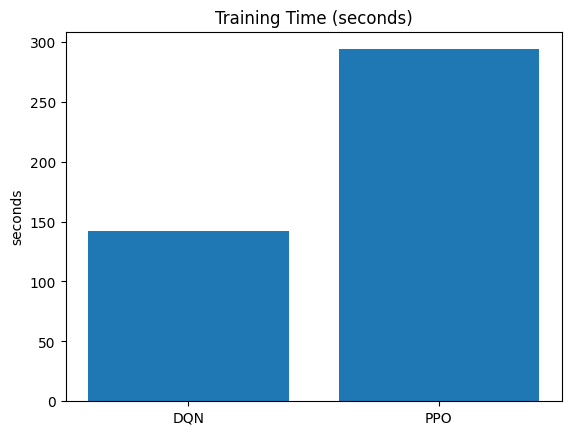

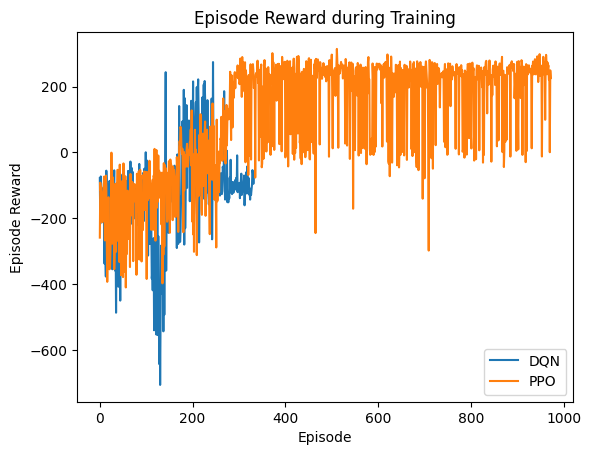

In [16]:
labels = ["DQN", "PPO"]
times = [dqn_train_time, ppo_train_time]

plt.figure()
plt.bar(labels, times)
plt.title("Training Time (seconds)")
plt.ylabel("seconds")
plt.show()

plt.figure()
plt.plot(dqn_logger.episode_rewards, label="DQN")
plt.plot(ppo_logger.episode_rewards, label="PPO")
plt.title("Episode Reward during Training")
plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.legend()
plt.show()

# **Question 8**

**DQN Tuned**

In [17]:
env_id = "LunarLander-v3"
train_steps_dqn_tuned = 200_000

env = make_env(env_id, seed=0)
dqn_tuned_logger = EpisodeRewardLogger()

dqn_tuned = DQN(
    policy="MlpPolicy",
    env=env,
    learning_rate=0.00063,
    buffer_size=50_000,
    batch_size=128,
    gamma=0.99,
    train_freq=4,
    target_update_interval=250,
    exploration_fraction=0.12,
    exploration_final_eps=0.1,
    learning_starts=0,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=0,
)

t0 = time.time()
dqn_tuned.learn(total_timesteps=train_steps_dqn_tuned, callback=dqn_tuned_logger)
dqn_tuned_train_time = time.time() - t0

env.close()

dqn_tuned_eval = evaluate_agent(dqn_tuned, env_id=env_id, n_episodes=5)
dqn_tuned_eval.mean(), dqn_tuned_train_time


(np.float64(209.50989080651448), 203.06408095359802)

**PPO Tuned**

In [18]:
env_id = "LunarLander-v3"
train_steps_ppo_tuned = 300_000

vec_env = make_vec_env(env_id, n_envs=16, seed=0, monitor_dir=None)
ppo_tuned_logger = EpisodeRewardLogger()

ppo_tuned = PPO(
    policy="MlpPolicy",
    env=vec_env,
    n_steps=1024,
    batch_size=64,
    n_epochs=4,
    gamma=0.999,
    gae_lambda=0.98,
    ent_coef=0.01,
    verbose=0,
)

t0 = time.time()
ppo_tuned.learn(total_timesteps=train_steps_ppo_tuned, callback=ppo_tuned_logger)
ppo_tuned_train_time = time.time() - t0

vec_env.close()

ppo_tuned_eval = evaluate_agent(ppo_tuned, env_id=env_id, n_episodes=5)
ppo_tuned_eval.mean(), ppo_tuned_train_time

(np.float64(-71.63527683569461), 189.06117916107178)

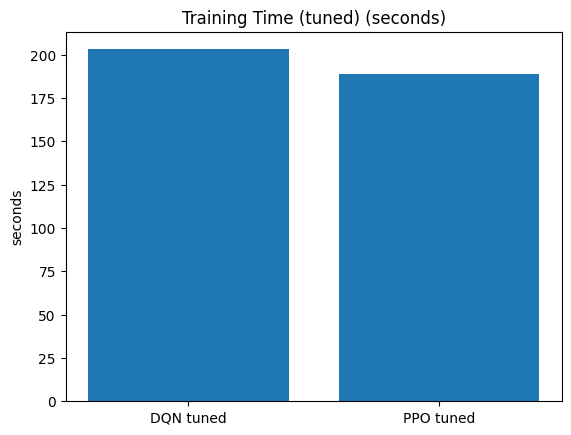

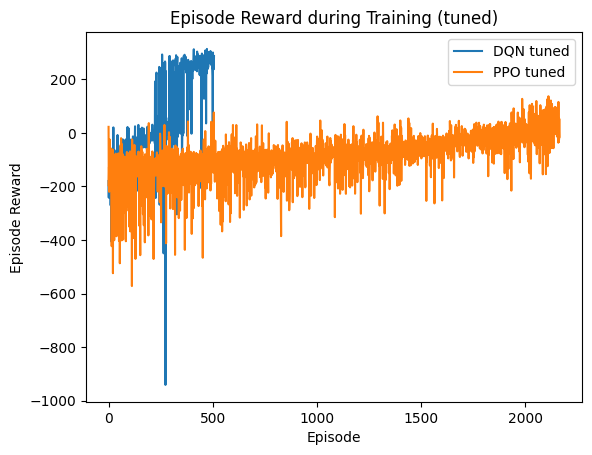

In [19]:
labels = ["DQN tuned", "PPO tuned"]
times = [dqn_tuned_train_time, ppo_tuned_train_time]

plt.figure()
plt.bar(labels, times)
plt.title("Training Time (tuned) (seconds)")
plt.ylabel("seconds")
plt.show()

plt.figure()
plt.plot(dqn_tuned_logger.episode_rewards, label="DQN tuned")
plt.plot(ppo_tuned_logger.episode_rewards, label="PPO tuned")
plt.title("Episode Reward during Training (tuned)")
plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.legend()
plt.show()